In [2]:
# 1. ENVIRONMENT SETUP
import os, random, warnings
import numpy as np
import pandas as pd
import pmdarima as pm
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['PYTHONHASHSEED'] = '0'

# Deterministic execution
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

def mape_score(y_true, y_pred): 
    return np.mean(np.abs((np.array(y_true) - np.array(y_pred)) / np.array(y_true))) * 100

def dm_test(actual, pred1, pred2):
    e1, e2 = actual - pred1, actual - pred2
    d = e1**2 - e2**2
    gamma0 = np.var(d)
    if gamma0 == 0: return 0, 1
    stat = np.mean(d) / np.sqrt(gamma0 / len(d))
    return stat, 2 * (1 - norm.cdf(abs(stat)))

def get_mape(y_true, y_pred): 
    return np.mean(np.abs((np.array(y_true) - np.array(y_pred)) / np.array(y_true))) * 100

Optimal ARIMA Order: (2, 1, 2)


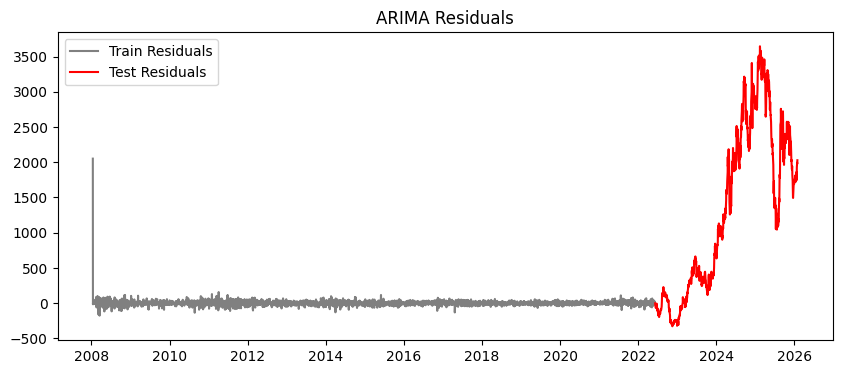

In [3]:
# 2. ARIMA MODELING
df = pd.read_csv('Data/Processed/Cleaned_Multivariate_Data.csv', index_col='Date', parse_dates=True)
features = ['Last Price', 'USD_Index', 'EFFR', 'Crude_Oil']
df = df[features]

train_size = int(len(df) * 0.8)
train_df, test_df = df.iloc[:train_size].copy(), df.iloc[train_size:].copy()
target_train, target_test = train_df['Last Price'], test_df['Last Price']

# Fit ARIMA
arima_model = pm.auto_arima(target_train, max_p=5, max_q=5, stepwise=True, suppress_warnings=True)
print(f"Optimal ARIMA Order: {arima_model.order}")

train_df['ARIMA_Pred'] = arima_model.predict_in_sample()
train_df['Residuals'] = target_train - train_df['ARIMA_Pred']
test_df['ARIMA_Pred'] = arima_model.predict(n_periods=len(target_test)).values
test_df['Residuals'] = target_test - test_df['ARIMA_Pred']

# Output: Residuals distribution
plt.figure(figsize=(10, 4))
plt.plot(train_df.index, train_df['Residuals'], label='Train Residuals', color='gray')
plt.plot(test_df.index, test_df['Residuals'], label='Test Residuals', color='red')
plt.title("ARIMA Residuals")
plt.legend()
plt.show()

In [4]:
# 3. DATA SCALING AND SEQUENCE GENERATION
time_steps = 60
nn_features = ['Residuals', 'USD_Index', 'EFFR', 'Crude_Oil']
std_features = ['Last Price', 'USD_Index', 'EFFR', 'Crude_Oil']

scaler_X_res, scaler_y_res = MinMaxScaler(), MinMaxScaler()
scaler_X_std, scaler_y_std = MinMaxScaler(), MinMaxScaler()

# 1. Tensors for Hybrid models (Target: Residuals)
X_train_res = scaler_X_res.fit_transform(train_df[nn_features])
y_train_res = scaler_y_res.fit_transform(train_df[['Residuals']])
X_test_res = scaler_X_res.transform(test_df[nn_features])
y_test_res = scaler_y_res.transform(test_df[['Residuals']])

# 2. Tensors for Standalone models (Target: Last Price)
X_train_std = scaler_X_std.fit_transform(train_df[std_features])
y_train_std = scaler_y_std.fit_transform(train_df[['Last Price']])
X_test_std = scaler_X_std.transform(test_df[std_features])
y_test_std = scaler_y_std.transform(test_df[['Last Price']])

def create_sequences(X, y, time_steps):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

X_train_seq_res, y_train_seq_res = create_sequences(X_train_res, y_train_res, time_steps)
X_test_seq_res, y_test_seq_res = create_sequences(X_test_res, y_test_res, time_steps)

X_train_seq_std, y_train_seq_std = create_sequences(X_train_std, y_train_std, time_steps)
X_test_seq_std, y_test_seq_std = create_sequences(X_test_std, y_test_std, time_steps)

print(f"Hybrid Tensors -> X_train: {X_train_seq_res.shape}, y_train: {y_train_seq_res.shape}")
print(f"Standalone Tensors -> X_train: {X_train_seq_std.shape}, y_train: {y_train_seq_std.shape}")

Hybrid Tensors -> X_train: (3622, 60, 4), y_train: (3622, 1)
Standalone Tensors -> X_train: (3622, 60, 4), y_train: (3622, 1)


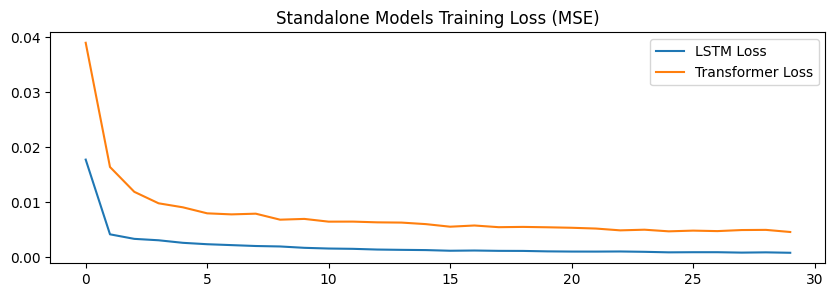

In [5]:
# 4. STANDALONE BASELINES 
input_shape = (X_train_seq_std.shape[1], X_train_seq_std.shape[2])

# LSTM Standalone
lstm_std = Sequential([
    LSTM(64, return_sequences=True, input_shape=input_shape), Dropout(0.2),
    LSTM(32, return_sequences=False), Dropout(0.2),
    Dense(16, activation='relu'), Dense(1)
])
lstm_std.compile(optimizer='adam', loss='mse')
hist_lstm_std = lstm_std.fit(X_train_seq_std, y_train_seq_std, epochs=30, batch_size=32, validation_split=0.1, verbose=0)

# Transformer Architecture
def build_transformer(input_shape):
    inputs = Input(shape=input_shape)
    x = MultiHeadAttention(num_heads=4, key_dim=64)(inputs, inputs)
    x = Dropout(0.2)(x)
    out1 = LayerNormalization(epsilon=1e-6)(inputs + x)
    x = Dense(128, activation="relu")(out1)
    x = Dense(input_shape[-1])(x)
    x = Dropout(0.2)(x)
    out2 = LayerNormalization(epsilon=1e-6)(out1 + x)
    x = GlobalAveragePooling1D()(out2)
    x = Dense(64, activation="relu")(x)
    x = Dropout(0.2)(x)
    outputs = Dense(1)(x)
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='mse')
    return model

trans_std = build_transformer(input_shape)
hist_trans_std = trans_std.fit(X_train_seq_std, y_train_seq_std, epochs=30, batch_size=32, validation_split=0.1, verbose=0)

lstm_std_pred = scaler_y_std.inverse_transform(lstm_std.predict(X_test_seq_std, verbose=0)).flatten()
trans_std_pred = scaler_y_std.inverse_transform(trans_std.predict(X_test_seq_std, verbose=0)).flatten()

# Output: Training Loss
plt.figure(figsize=(10, 3))
plt.plot(hist_lstm_std.history['loss'], label='LSTM Loss')
plt.plot(hist_trans_std.history['loss'], label='Transformer Loss')
plt.title("Standalone Models Training Loss (MSE)")
plt.legend()
plt.show()

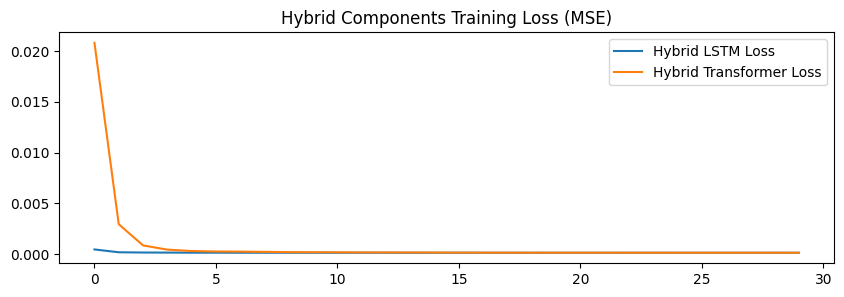

In [6]:
# 5.HYBRID COMPONENTS (TARGET: RESIDUALS)
lstm_res = Sequential([
    LSTM(64, return_sequences=True, input_shape=input_shape), Dropout(0.2),
    LSTM(32, return_sequences=False), Dropout(0.2),
    Dense(16, activation='relu'), Dense(1)
])
lstm_res.compile(optimizer='adam', loss='mse')
hist_lstm_res = lstm_res.fit(X_train_seq_res, y_train_seq_res, epochs=30, batch_size=32, validation_split=0.1, verbose=0)

trans_res = build_transformer(input_shape)
hist_trans_res = trans_res.fit(X_train_seq_res, y_train_seq_res, epochs=30, batch_size=32, validation_split=0.1, verbose=0)

lstm_res_pred = scaler_y_res.inverse_transform(lstm_res.predict(X_test_seq_res, verbose=0)).flatten()
trans_res_pred = scaler_y_res.inverse_transform(trans_res.predict(X_test_seq_res, verbose=0)).flatten()

actual = target_test.values[time_steps:]
arima_base = test_df['ARIMA_Pred'].values[time_steps:]

# Y_t = L_t + N_t
hybrid_lstm = arima_base + lstm_res_pred
hybrid_trans = arima_base + trans_res_pred

# Output: Training Loss
plt.figure(figsize=(10, 3))
plt.plot(hist_lstm_res.history['loss'], label='Hybrid LSTM Loss')
plt.plot(hist_trans_res.history['loss'], label='Hybrid Transformer Loss')
plt.title("Hybrid Components Training Loss (MSE)")
plt.legend()
plt.show()

In [7]:
# 6. PERFORMANCE EVALUATION & STATISTICAL TESTING
results = []
models = {
    "ARIMA": arima_base,
    "LSTM (Standalone)": lstm_std_pred,
    "Transformer (Standalone)": trans_std_pred,
    "ARIMA-LSTM (Hybrid)": hybrid_lstm,
    "ARIMA-Transformer (Hybrid)": hybrid_trans
}

for name, pred in models.items():
    results.append({
        "Model": name,
        "MAE": round(mean_absolute_error(actual, pred), 2),
        "RMSE": round(np.sqrt(mean_squared_error(actual, pred)), 2),
        "MAPE (%)": round(get_mape(actual, pred), 2),
        "R2": round(r2_score(actual, pred), 4)
    })

results_df = pd.DataFrame(results).set_index("Model")
display(results_df)

# Diebold-Mariano Test
stat, p_val = dm_test(actual, arima_base, hybrid_trans)
print(f"Diebold-Mariano Test (ARIMA vs ARIMA-Transformer):")
print(f"Statistic: {stat:.4f} | p-value: {p_val:.4f}")

,MAE,RMSE,MAPE (%),R2
Model,,,,
ARIMA,1460.32,1834.38,34.86,-1.4774
LSTM (Standalone),452.81,608.40,10.40,0.7275
Transformer (Standalone),1099.31,1446.14,25.83,-0.5397
ARIMA-LSTM (Hybrid),1409.86,1767.13,33.73,-1.2991
ARIMA-Transformer (Hybrid),1536.42,1927.38,36.67,-1.7350


Diebold-Mariano Test (ARIMA vs ARIMA-Transformer):
Statistic: -27.9978 | p-value: 0.0000


In [ ]:
# CELL 7: 7-DAY RECURSIVE FORECAST (STANDALONE LSTM)
print("[INFO] Generating 7-day recursive forecast using optimal model (Standalone LSTM).")

future_steps = 7
# Lấy 60 ngày cuối cùng của tập Test chuẩn để làm điểm tựa
current_batch = X_test_std[-time_steps:].reshape(1, time_steps, len(std_features))
future_price_scaled = []

for _ in range(future_steps):
    # Trích xuất chính xác số vô hướng (Scalar) để tránh Dimension Error
    pred_val = lstm_std.predict(current_batch, verbose=0)[0][0]
    future_price_scaled.append([pred_val]) 
    
    # Cập nhật giá trị dự báo vào hàng tiếp theo (Ceteris Paribus: Giữ nguyên vĩ mô)
    new_row = current_batch[0, -1, :].copy()
    new_row[0] = pred_val  
    current_batch = np.append(current_batch[:, 1:, :], [[new_row]], axis=1)

# Giải mã giá trị thực tế
final_forecast = scaler_y_std.inverse_transform(future_price_scaled).flatten()

# Tính toán biên độ rủi ro dựa trên phương sai sai số của LSTM Độc lập
margin = 1.96 * np.sqrt(np.var(actual - lstm_std_pred))
lower_bound = final_forecast - margin

forecast_df = pd.DataFrame({
    'Horizon': [f"T+{i+1}" for i in range(future_steps)],
    'Forecast (USD/Ton)': np.round(final_forecast, 2),
    'Risk Floor 95% (USD/Ton)': np.round(lower_bound, 2)
})

print("-" * 50)
print(forecast_df.to_string(index=False))
print("-" * 50)

# os.makedirs('reports/figures', exist_ok=True)
# forecast_df.to_csv('reports/Future_7Days.csv', index=False)

[INFO] Generating 7-day recursive forecast using optimal model (Standalone LSTM).
--------------------------------------------------
Horizon  Forecast (USD/Ton)  Risk Floor 95% (USD/Ton)
    T+1             3576.68                   2775.72
    T+2             3375.15                   2574.19
    T+3             3175.63                   2374.68
    T+4             3003.17                   2202.22
    T+5             2867.42                   2066.46
    T+6             2768.18                   1967.23
    T+7             2699.51                   1898.56
--------------------------------------------------
